# Simulated EMG Signal Exploration

This notebook introduces the basic signal-processing pipeline for MyoBridge.

The notebook will:

- generate a synthetic EMG-like signal
- visualise the raw signal
- rectify the signal
- calculate an RMS envelope
- inspect the signal in the frequency domain
- divide the signal into windows

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
sampling_frequency = 1000
duration_seconds = 5

time = np.arange( 0, duration_seconds, 1 / sampling_frequency )

print("Number of samples:", len(time))
print("Duration:", time[-1], "seconds")

Number of samples: 5000
Duration: 4.999 seconds


In [38]:
np.random.seed(42)

background_noise = 0.03 * np.random.randn(len(time))

muscle_activity = np.zeros(len(time))

active_region = (time >= 1.5) & (time <= 3.5)

muscle_activity[active_region] = ( 0.25 * np.random.randn(np.sum(active_region)))

emg_signal = background_noise + muscle_activity

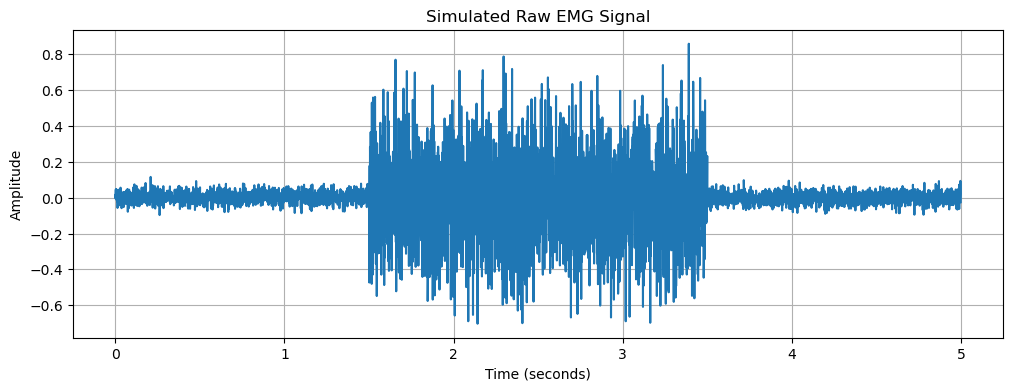

In [39]:
plt.figure(figsize=(12, 4))
plt.plot(time, emg_signal)

plt.title("Simulated Raw EMG Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()

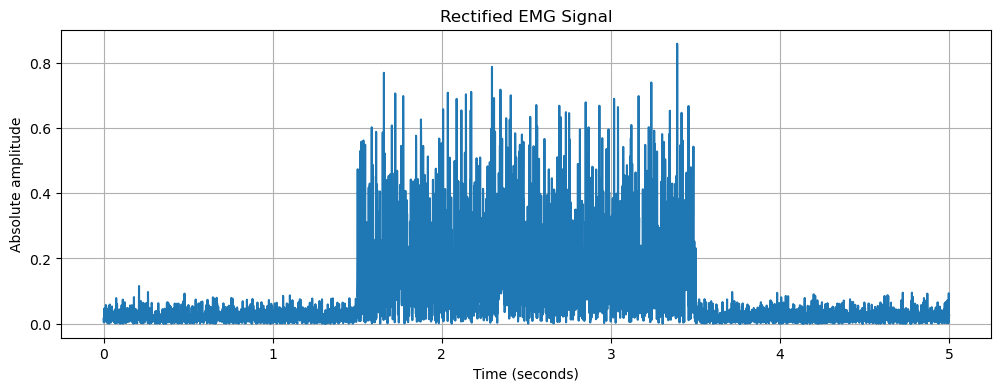

In [40]:
rectified_signal = np.abs(emg_signal)

plt.figure(figsize=(12, 4))
plt.plot(time, rectified_signal)

plt.title("Rectified EMG Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Absolute amplitude")
plt.grid(True)

plt.show()

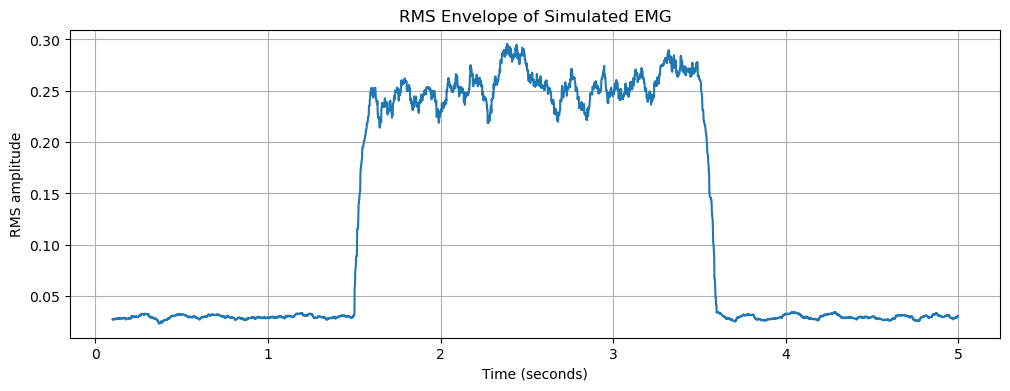

In [41]:
window_size = 100

rms_signal = np.sqrt(
    pd.Series(emg_signal ** 2)
    .rolling(window=window_size)
    .mean()
)

plt.figure(figsize=(12, 4))
plt.plot(time, rms_signal)

plt.title("RMS Envelope of Simulated EMG")
plt.xlabel("Time (seconds)")
plt.ylabel("RMS amplitude")
plt.grid(True)

plt.show()

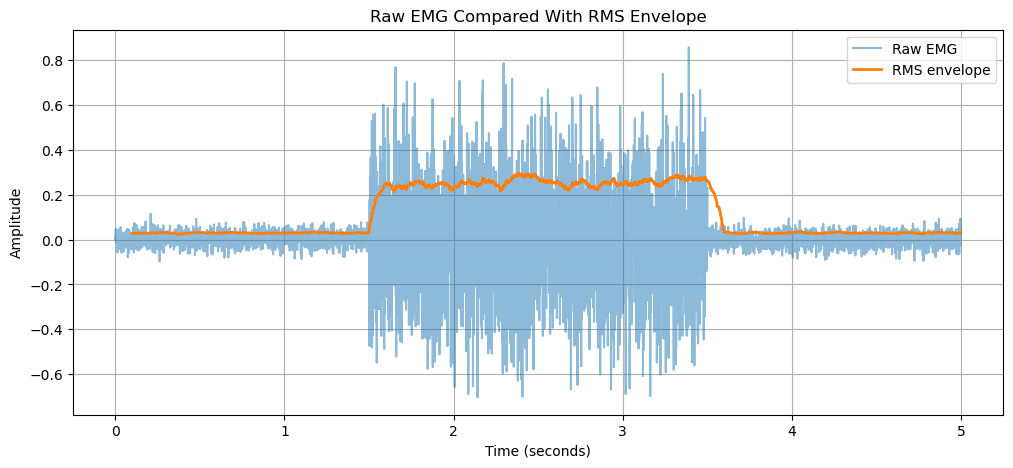

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(time, emg_signal, alpha=0.5, label="Raw EMG")
plt.plot(time, rms_signal, linewidth=2, label="RMS envelope")

plt.title("Raw EMG Compared With RMS Envelope")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()

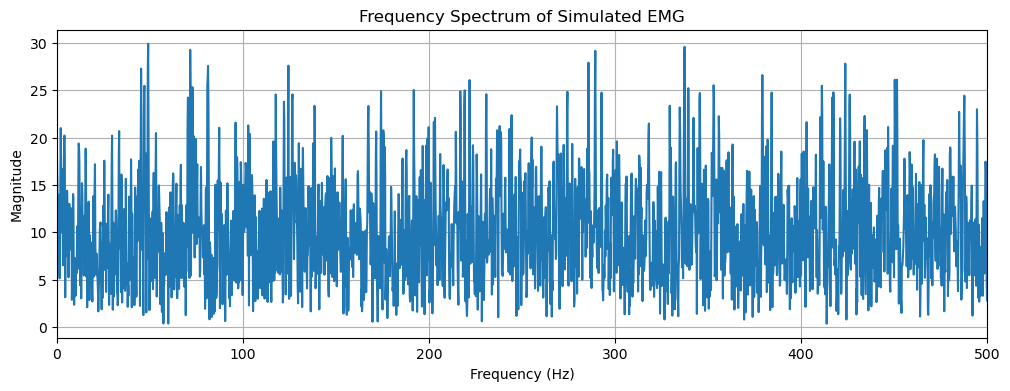

In [43]:
number_of_samples = len(emg_signal)

fft_values = np.fft.rfft(emg_signal)
fft_frequencies = np.fft.rfftfreq(
    number_of_samples,
    d=1 / sampling_frequency
)

fft_magnitude = np.abs(fft_values)

plt.figure(figsize=(12, 4))
plt.plot(fft_frequencies, fft_magnitude)

plt.title("Frequency Spectrum of Simulated EMG")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 500)
plt.grid(True)

plt.show()

In [44]:
window_length_samples = 250
window_step_samples = 125

windows = []

for start_index in range(
    0,
    len(emg_signal) - window_length_samples + 1,
    window_step_samples
):
    end_index = start_index + window_length_samples
    signal_window = emg_signal[start_index:end_index]
    windows.append(signal_window)

print("Number of windows:", len(windows))
print("Samples per window:", len(windows[0]))

Number of windows: 39
Samples per window: 250


In [45]:
feature_rows = []

for window_number, signal_window in enumerate(windows):
    mean_absolute_value = np.mean(np.abs(signal_window))
    rms_value = np.sqrt(np.mean(signal_window ** 2))
    variance_value = np.var(signal_window)
    waveform_length = np.sum(np.abs(np.diff(signal_window)))

    feature_rows.append(
        {
            "window_number": window_number,
            "mean_absolute_value": mean_absolute_value,
            "rms": rms_value,
            "variance": variance_value,
            "waveform_length": waveform_length,
        }
    )

feature_table = pd.DataFrame(feature_rows)

feature_table.head()


,window_number,mean_absolute_value,rms,variance,waveform_length
0,0,0.022856,0.028924,0.000837,8.423520
1,1,0.022624,0.028622,0.000815,8.168676
2,2,0.023898,0.029886,0.000893,8.286149
3,3,0.024887,0.030766,0.000946,8.652067
4,4,0.023639,0.029691,0.000877,8.451920


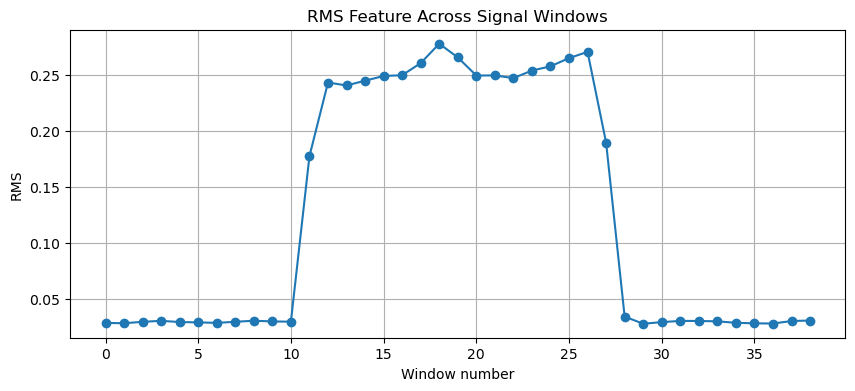

In [46]:
plt.figure(figsize=(10, 4))
plt.plot(
    feature_table["window_number"],
    feature_table["rms"],
    marker="o"
)

plt.title("RMS Feature Across Signal Windows")
plt.xlabel("Window number")
plt.ylabel("RMS")
plt.grid(True)

plt.show()

## Day 2 observations

- The raw EMG-like signal contains rapid positive and negative fluctuations.
- Rectification converts the signal into positive magnitudes.
- The RMS envelope makes periods of stronger activity easier to identify.
- The FFT shows the signal in the frequency domain.
- Windowing converts a continuous signal into short segments suitable for machine learning.
- Simple features such as RMS, variance and waveform length change during simulated muscle activity.

## Limitations

This is only a synthetic signal. Real surface EMG will include motion artefacts, electrode noise, interference and changes caused by electrode placement.